## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

## Normal Baseline Data

In [2]:
# Load 97.mat file
data = loadmat('97.mat')

# View available variables
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


In [3]:
# Load 105.mat file
data = loadmat('105.mat')
# View available variables
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X105_DE_time', 'X105_FE_time', 'X105_BA_time', 'X105RPM'])


In [4]:
# Load 118.mat file
data = loadmat('118.mat')
# View available variables
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X118_DE_time', 'X118_FE_time', 'X118_BA_time', 'X118RPM'])


In [5]:
# Load 130.mat file
data = loadmat('130.mat')
# View available variables
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X130_DE_time', 'X130_FE_time', 'X130_BA_time', 'X130RPM'])


# Function to Load CWRU Vibration Signals

In [6]:
def load_cwru_signal(filename, variable_name):
    data = loadmat(filename)
    signal = data[variable_name]
    signal = signal.flatten()
    return signal

# Load Normal Bearing Signal

In [7]:
normal_signal = load_cwru_signal(
    "97.mat",
    "X097_DE_time"
)

# Load Inner Race Fault Signal

In [8]:
inner_signal = load_cwru_signal(
    "105.mat",
    "X105_DE_time"  
)

# Load Ball Fault Signal

In [9]:
ball_signal = load_cwru_signal(
    "118.mat",
    "X118_DE_time" 
)

# Load Outer Race Fault Signal

In [10]:
outer_signal = load_cwru_signal(
    "130.mat",
    "X130_DE_time" 
)

# Verifying Signal Dimension

In [11]:
print (normal_signal.shape)
print (inner_signal.shape)
print (ball_signal.shape)
print (outer_signal.shape)

(243938,)
(121265,)
(122571,)
(121991,)


# RPM extraction

In [35]:
def get_rpm(filename):

    data = loadmat(filename)

    rpm_key = [
        k for k in data.keys()
        if "RPM" in k
    ][0]

    return data[rpm_key].item()

# Test:

In [36]:
print(get_rpm("97.mat"))
print(get_rpm("105.mat"))

1796
1797


# Visualise Normal Bearing Signal

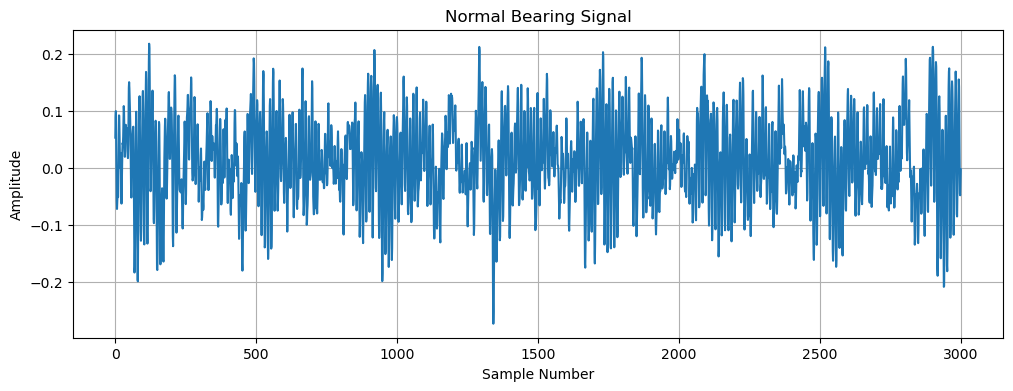

In [12]:
plt.figure(figsize=(12,4))
plt.plot(normal_signal[:3000])
plt.title("Normal Bearing Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Visualise Inner Race Fault Signal

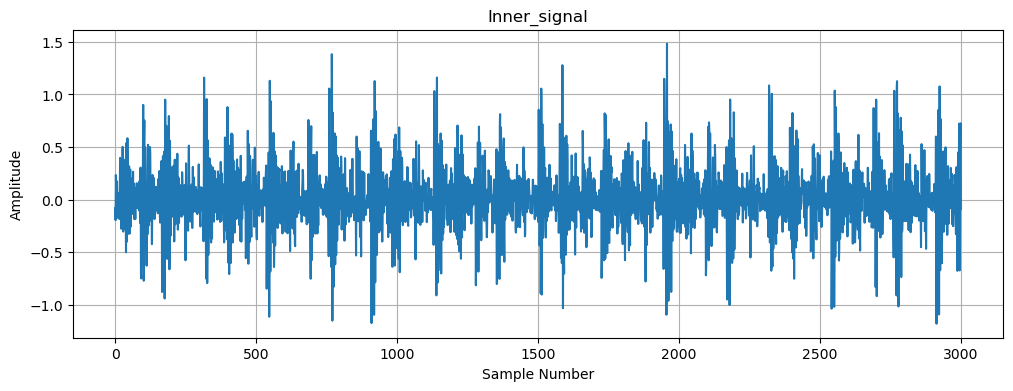

In [13]:
plt.figure(figsize=(12,4))
plt.plot(inner_signal[:3000])
plt.title('Inner_signal')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Visualise Ball Fault Signal

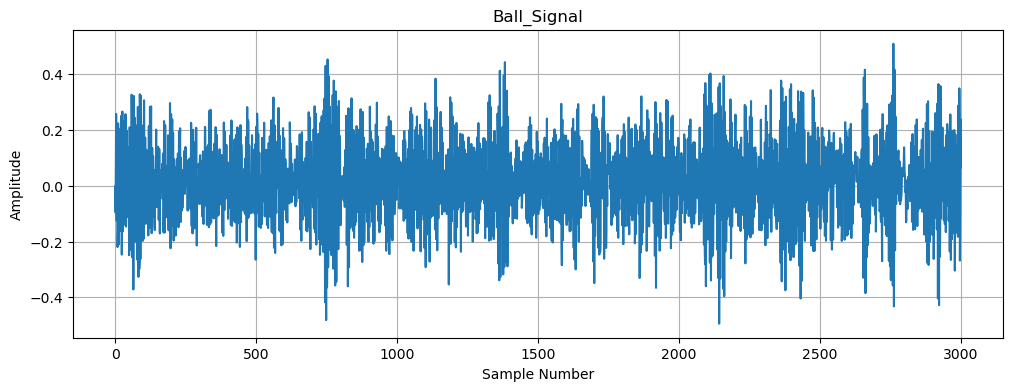

In [14]:
plt.figure(figsize=(12,4))
plt.plot(ball_signal[:3000])
plt.title("Ball_Signal")
plt.xlabel("Sample Number")
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Visualise Outer Race Fault Signal

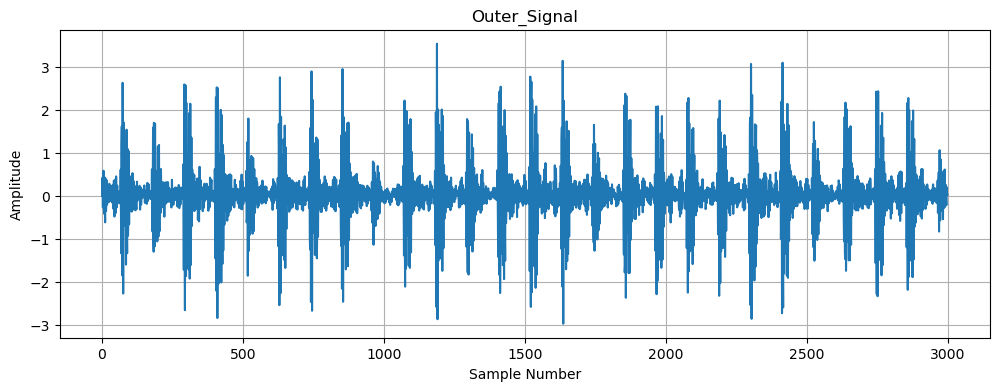

In [15]:
plt.figure(figsize=(12,4))
plt.plot(outer_signal[:3000])
plt.title("Outer_Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Summary of Loaded Bearing Classes

In [16]:
bearing_summary = pd.DataFrame({

    "Bearing Condition":[
        "Normal",
        "Inner Race Fault",
        "Ball Fault",
        "Outer Race Fault"
    ],

    "File":[
        "97.mat",
        "105.mat",
        "118.mat",
        "130.mat"
    ],

    "Signal Length":[
        len(normal_signal),
        len(inner_signal),
        len(ball_signal),
        len(outer_signal)
    ]

})

bearing_summary

,Bearing Condition,File,Signal Length
0,Normal,97.mat,243938
1,Inner Race Fault,105.mat,121265
2,Ball Fault,118.mat,122571
3,Outer Race Fault,130.mat,121991
